In [106]:
# Import Libs

import numpy as np

import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers


In [107]:
num_classes = 10

input_shape= (32,32,3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3) - y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3) - y_test shape: (10000, 1)


In [108]:
x_train=x_train[:500]
y_train=y_train[:500]
x_test=x_test[:500]
y_test=y_test[:500]

In [109]:

input_shape= (32,32,3)


In [110]:
learning_rate=0.001

weigth_decay=0.0001

batch_size=256

num_epochs =40

image_size= 72  # we'll resize input images to this size

patch_size= 6 # Size of the patches to be extract from the imput images
num_patches=(image_size // patch_size) ** 2
projection_dim=64

num_heads=4

transformer_units =[
    projection_dim*2,
    projection_dim

]#Size of the transformer Layers

transformer_layers=8

mlp_head_units=[2048, 1024] # Size of the dense Layers of the final classifier

In [111]:
data_augmentation= keras.Sequential(

[ 
    layers.Normalization(), 
    layers.Resizing(image_size, image_size), 
    layers.RandomFlip("horizontal"), 
    layers.RandomRotation(factor=0.02),
    layers.RandomZoom( 
        height_factor =0.2, width_factor = 0.2)

],

name="data_augmentation"


)

data_augmentation.layers[0].adapt(x_train)

In [112]:
def mlp(x, hidden_units, dropout_rate):

    for units in hidden_units: 
        x =layers.Dense(units, activation = tf.nn.gelu) (x) 
        x =layers.Dropout(dropout_rate)(x)
    return x

In [113]:
class Patches (layers. Layer):

    def __init__(self, patch_size,):

        super(Patches, self).__init__()

        self.patch_size=patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches=tf.image.extract_patches(

            images=images,

            sizes=[1, self.patch_size, self.patch_size, 1],

            strides=[1,self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],

            padding="VALID",
        )
      

        patch_dims = patches.shape[-1]
        patches= tf.reshape(patches, [batch_size,-1,patch_dims])

        return patches

Image size: 72 X 72
Patch size: 6 X 6
Patches per image: 144
Elements per patch: 108


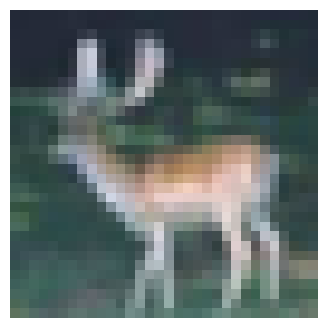

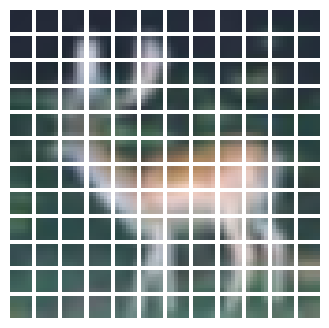

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4)) 
image=x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8")) 
plt.axis("off")

resized_image = tf.image.resize(
     tf.convert_to_tensor ([image]),size=(image_size, image_size) 
)

patches= Patches(patch_size)(resized_image)

print(f"Image size: {image_size} X {image_size}") 
print(f"Patch size: {patch_size} X {patch_size}")

print(f"Patches per image: {patches.shape[1]}")

print(f"Elements per patch: {patches.shape[-1]}")

n=int(np.sqrt(patches.shape[1]))

plt.figure(figsize=(4,4))

for i, patch in enumerate(patches[0]): 
    ax =plt.subplot(n, n, i+1)

    patch_img=tf.reshape(patch, (patch_size, patch_size, 3)) 
    plt.imshow(patch_img.numpy().astype("uint8"))

    plt.axis("off")

In [115]:
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):

        super (PatchEncoder, self).__init__()

        self.num_patches=num_patches

        self.projection=layers.Dense(units=projection_dim)

        self.position_embedding=layers.Embedding(

        input_dim=num_patches, output_dim=projection_dim
    )
    def call(self, patch):

        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded =self.projection(patch) +self.position_embedding(positions)

        return encoded

In [116]:
def create_vit_classifier():

    inputs =layers.Input (shape=input_shape)

    #Augment data.

    augmented= data_augmentation(inputs)

    #Create patches.

    patches= Patches(patch_size)(augmented)

    #Encode patches.

    encoded_patches=PatchEncoder(num_patches, projection_dim) (patches)

    #Create multiple layers of the Transformer block

    for _ in range(transformer_layers): 
        #Layer normalization 1

        x1=layers.LayerNormalization(epsilon=1e-6) (encoded_patches)

        #Create a multi-head attension Layer

        attention_output =layers.MultiHeadAttention(

            num_heads=num_heads, key_dim=projection_dim, dropout=0.1 
        )(x1,x1)

        #skip connection 1.

        x2=layers.Add()([attention_output, encoded_patches])

        #Layer normalization 2.

        x3=layers.LayerNormalization(epsilon=1e-6)(x2)

        #MLP.

        x3=mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)

        # Skip connection2. 
        encoded_patches=layers.Add()([x3,x2])

    #Create a [batch_size, projection_dim) tensor 
    representation =layers.LayerNormalization(epsilon=1e-6)(encoded_patches) 
    representation =layers.Flatten() (representation) 
    representation =layers.Dropout (0.5) (representation)
    #Add MLP.

    features= mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)

    #Classify outputs.

    logits =layers.Dense(num_classes) (features)

    #Create the Keras Model

    model=keras.Model(inputs=inputs, outputs=logits)

    return model

In [133]:
weight_decay = 1e-4  # Adjust this value as needed
learning_rate = 1e-3  # Adjust this value as needed
def run_experiment (model):

    optimizer =tf.optimizers.AdamW(

    learning_rate=learning_rate,
    weight_decay=weight_decay
    )
    model.compile(

        optimizer=optimizer,

        loss=keras.losses. SparseCategoricalCrossentropy(from_logits=True),

        metrics=[

            keras.metrics.SparseCategoricalAccuracy (name="accuracy"),

            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top_5_accuracy"),

        ]
    )
    checkpoint_filepath="/tmp/checkpoint.weights.h5"

    checkpoint_callback =keras.callbacks.ModelCheckpoint (

        checkpoint_filepath,

        monitor="val_accuarcy",

        save_best_only=True,

        save_weights_only=True,
    )
    history= model.fit(

        x=x_train,

        y=y_train,

        batch_size=batch_size,

        epochs=num_epochs,

        validation_split=0.1,

        callbacks=[checkpoint_callback],
    )
    model.load_weights(checkpoint_filepath)

    _, accuracy, top_5_accuracy=model.evaluate(x_test, y_test)

    print(f"Test accuracy: {round(accuracy* 100,2)}%")

    print(f"Test Top_5_accuracy: {round(top_5_accuracy *100, 2)}%")

In [136]:
import os

checkpoint_dir = '/tmp'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

checkpoint_filepath = os.path.join(checkpoint_dir, "checkpoint.weights.h5")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)
vit_classifier =create_vit_classifier()
history=run_experiment(vit_classifier)


Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.1035 - loss: 5.0163 - top_5_accuracy: 0.5395 - val_accuracy: 0.2400 - val_loss: 4.1774 - val_top_5_accuracy: 0.7600
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2114 - loss: 5.6818 - top_5_accuracy: 0.6766 - val_accuracy: 0.2000 - val_loss: 2.8285 - val_top_5_accuracy: 0.7800
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2031 - loss: 3.8285 - top_5_accuracy: 0.6958 - val_accuracy: 0.2200 - val_loss: 2.5260 - val_top_5_accuracy: 0.7400
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.1803 - loss: 3.0915 - top_5_accuracy: 0.6932 - val_accuracy: 0.1800 - val_loss: 2.2677 - val_top_5_accuracy: 0.7600
Epoch 5/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2164 - loss: 2.7050 - top_5_accuracy: 0.6743 - val_accuracy: 0.2200 - val_loss: 2.0603 - val_top_5_accuracy: 0.7800
Epoch 6/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2205 - loss: 2.4450 - top_5_accuracy: 0.7186 - val_ac

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/tmp/checkpoint.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)